# 04. Riepilogo Risultati

In [2]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, adjusted_rand_score

# Path moduli
sys.path.append(os.path.abspath('modules'))

from data_loader import load_cancer_data
from preprocessing import GenePreprocessor
from models_factory import get_supervised_model, get_unsupervised_model

sns.set_theme(style='whitegrid')
SEED = 42

## 1. Tabella Riassuntiva 
File JSON salvati nei notebook precedenti.

In [ ]:
results_path = 'results'
summary = []

if os.path.exists(results_path):
    for file in os.listdir(results_path):
        if file.endswith('.json'):
            with open(os.path.join(results_path, file), 'r') as f:
                data = json.load(f)
                model_name = file.replace('.json', '')
                
                #metrica principale da mostrare (Accuracy o ARI)
                summary.append({
                    'Modello': model_name.upper(),
                    'Accuracy/ARI': data.get('accuracy') if 'accuracy' in data else data.get('ari'),
                    'Tipo': 'Supervisionato' if 'accuracy' in data else 'Non Supervisionato'
                })

if summary:
    df_summary = pd.DataFrame(summary).sort_values(by='Accuracy/ARI', ascending=False)
    display(df_summary)
else:
    print("Nessun risultato trovato. Esegui prima i notebook 02 e 03.")

,Modello,Accuracy/ARI,Tipo
1,LOGISTIC_REGRESSION,1.000000,Supervisionato
4,SVM,0.993789,Supervisionato
3,SPECTRAL,0.983157,Non Supervisionato
2,RANDOM_FOREST,0.881988,Supervisionato
0,KMEANS,0.796980,Non Supervisionato


## 2. Valutiamo come cambiano le performance di un modello (es: SVM e KMeans) variando il numero di componenti PCA.


In [4]:
# Caricamento dati grezzi per il loop
X, y = load_cancer_data(data_path='../archive/data.csv', labels_path='../archive/labels.csv')

n_components_list = [2, 5, 10, 20, 50, 100, 200]
results_sensitivity = []

for n in n_components_list:
    print(f"Test con n_components={n}...", end=' ')
    
    # Preprocessing con n componenti fisse
    pre = GenePreprocessor(variance_threshold=0.1, n_components=n, seed=SEED)
    X_pca, y_enc = pre.fit_transform(X, y)
    
    # Supervisionato: SVM
    svm = get_supervised_model('svm', seed=SEED)
    svm.fit(X_pca, y_enc)
    acc = accuracy_score(y_enc, svm.predict(X_pca)) 
    
    # Non Supervisionato: KMeans
    km = get_unsupervised_model('kmeans', n_clusters=5, seed=SEED)
    km_labels = km.fit_predict(X_pca)
    ari = adjusted_rand_score(y_enc, km_labels)
    
    results_sensitivity.append({'n': n, 'Accuracy (SVM)': acc, 'ARI (KMeans)': ari})
    print("OK")

df_sens = pd.DataFrame(results_sensitivity)

Test con n_components=2... OK
Test con n_components=5... OK
Test con n_components=10... OK
Test con n_components=20... OK
Test con n_components=50... OK
Test con n_components=100... OK
Test con n_components=200... OK


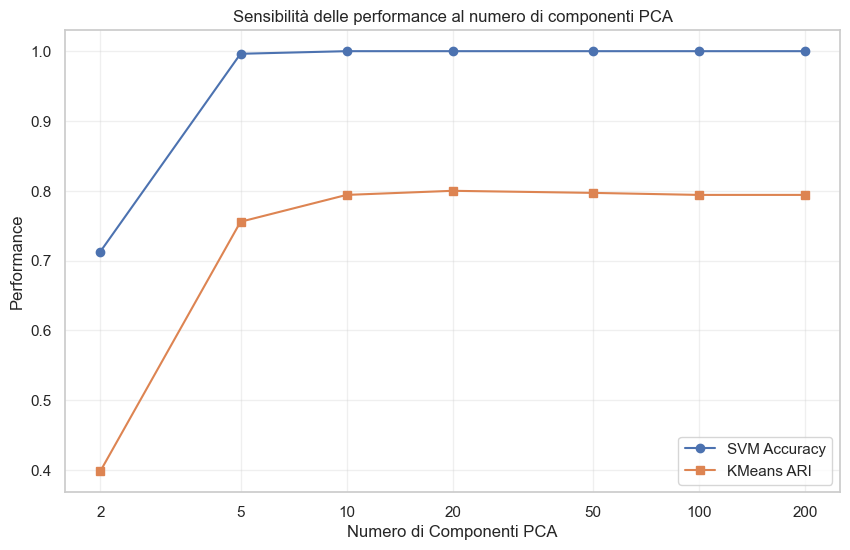

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(df_sens['n'], df_sens['Accuracy (SVM)'], marker='o', label='SVM Accuracy')
plt.plot(df_sens['n'], df_sens['ARI (KMeans)'], marker='s', label='KMeans ARI')
plt.xscale('log')
plt.xticks(n_components_list, n_components_list)
plt.xlabel('Numero di Componenti PCA')
plt.ylabel('Performance')
plt.title('Sensibilità delle performance al numero di componenti PCA')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()